In [34]:
import pandas as pd
import numpy as np

df = pd.read_csv("student_performance.csv")

df.head()

,Student_ID,Age,Gender,Study_Hours,Attendance(%),Test_Score,Grade
0,S0524,21,Female,2.7,74.0,37.0,F
1,S0603,19,Male,1.5,93.1,26.0,F
2,S0527,20,Female,6.8,97.2,88.0,A
3,S0032,18,Female,6.2,93.5,55.0,C
4,S0617,21,Male,7.4,99.2,77.0,B


In [35]:
# Display structure of dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Student_ID     1020 non-null   str    
 1   Age            1020 non-null   int64  
 2   Gender         1020 non-null   str    
 3   Study_Hours    989 non-null    float64
 4   Attendance(%)  990 non-null    float64
 5   Test_Score     1020 non-null   float64
 6   Grade          1011 non-null   str    
dtypes: float64(3), int64(1), str(3)
memory usage: 55.9 KB


In [36]:
# Count missing values in each column
print(df.isnull().sum())

Student_ID        0
Age               0
Gender            0
Study_Hours      31
Attendance(%)    30
Test_Score        0
Grade             9
dtype: int64


In [37]:
# Count duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 20


In [38]:
# Remove duplicate rows if they exist
df.drop_duplicates(inplace=True)

In [39]:
# Fill numerical missing values with median

df["Age"] = df["Age"].fillna(df["Age"].median())

df["Study_Hours"] = df["Study_Hours"].fillna(
    df["Study_Hours"].median()
)

df["Attendance(%)"] = df["Attendance(%)"].fillna(
    df["Attendance(%)"].median()
)

df["Test_Score"] = df["Test_Score"].fillna(
    df["Test_Score"].median()
)

In [40]:
# Fill categorical columns with mode

df["Gender"] = df["Gender"].fillna(
    df["Gender"].mode()[0]
)

df["Grade"] = df["Grade"].fillna(
    df["Grade"].mode()[0]
)

In [41]:
# Summary statistics
df.describe()

,Age,Study_Hours,Attendance(%),Test_Score
count,1000.0000,1000.000000,1000.000000,1000.00000
mean,20.9600,5.159700,84.850400,49.80800
std,2.0036,2.522282,9.820518,21.18745
min,18.0000,-2.000000,50.300000,0.00000
25%,19.0000,3.700000,78.000000,35.00000
50%,21.0000,5.100000,85.000000,50.00000
75%,23.0000,6.300000,91.725000,64.00000
max,24.0000,25.000000,115.600000,100.00000


In [42]:
#print  mean of numerical columns
print(df.mean(numeric_only=True))

Age              20.9600
Study_Hours       5.1597
Attendance(%)    84.8504
Test_Score       49.8080
dtype: float64


In [43]:
#print meadian of numerical columns
print(df.median(numeric_only=True))

Age              21.0
Study_Hours       5.1
Attendance(%)    85.0
Test_Score       50.0
dtype: float64


In [44]:
#print mode of categorical columns
print(df.mode().iloc[0])

Student_ID       S0001
Age               18.0
Gender            Male
Study_Hours        5.1
Attendance(%)     85.0
Test_Score        49.0
Grade                F
Name: 0, dtype: object


In [45]:
#print standard deviation for numerical columns
print(df.std(numeric_only=True))

Age               2.003600
Study_Hours       2.522282
Attendance(%)     9.820518
Test_Score       21.187450
dtype: float64


In [46]:
#print variance for numerical columns
print(df.var(numeric_only=True))

Age                4.014414
Study_Hours        6.361908
Attendance(%)     96.442582
Test_Score       448.908044
dtype: float64


In [47]:
#print minimun and maximum values for numerical columns
print(df.min(numeric_only=True))

print(df.max(numeric_only=True))

Age              18.0
Study_Hours      -2.0
Attendance(%)    50.3
Test_Score        0.0
dtype: float64
Age               24.0
Study_Hours       25.0
Attendance(%)    115.6
Test_Score       100.0
dtype: float64


In [48]:
#print interquartile range for Test_Score column and IQR for Test_Score column
Q1 = df["Test_Score"].quantile(0.25)

Q3 = df["Test_Score"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 35.0
Q3: 64.0
IQR: 29.0


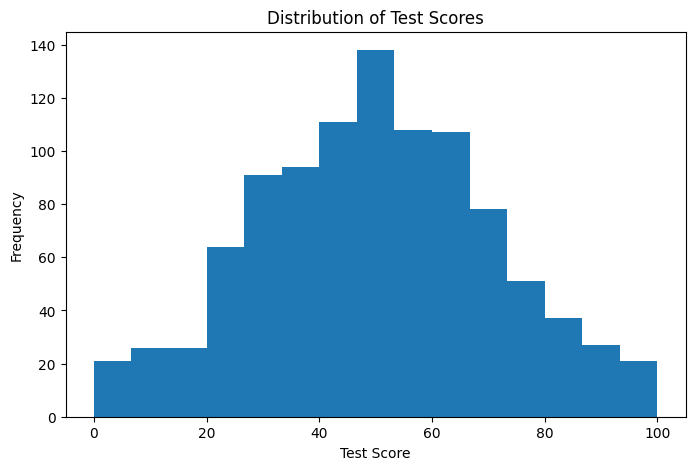

In [49]:
# Histogram showing distribution of test scores

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Test_Score"], bins=15)

plt.title("Distribution of Test Scores")
plt.xlabel("Test Score")
plt.ylabel("Frequency")

plt.show()

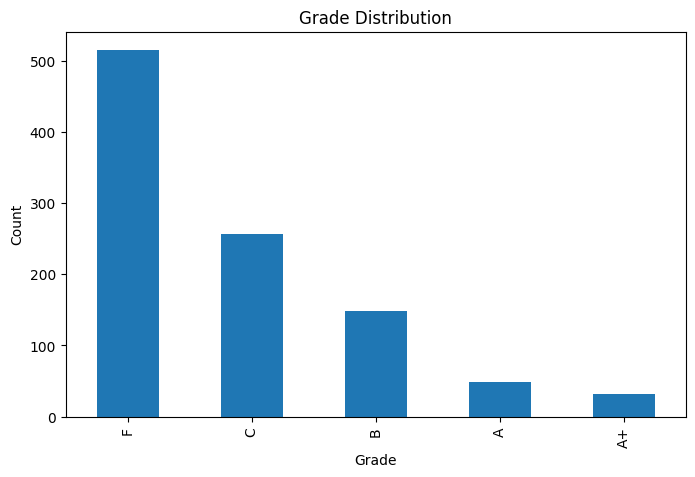

In [50]:
# Bar chart Comparing number of students in each grade

plt.figure(figsize=(8,5))

df["Grade"].value_counts().plot(kind="bar")

plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Count")

plt.show()

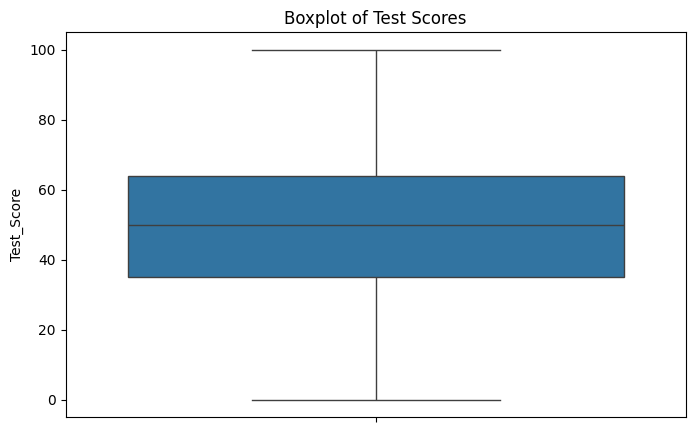

In [51]:
# Box plot detecting outliers in test scores

import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(y=df["Test_Score"])

plt.title("Boxplot of Test Scores")

plt.show()

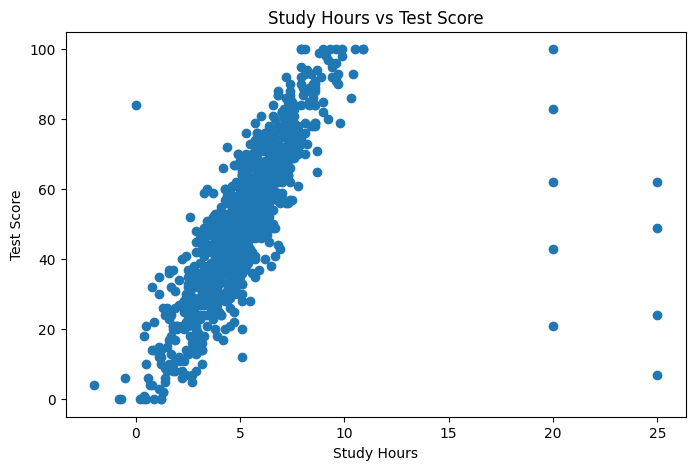

In [52]:
# Scatter plot showing relationship between study hours and test scores

plt.figure(figsize=(8,5))

plt.scatter(
    df["Study_Hours"],
    df["Test_Score"]
)

plt.title("Study Hours vs Test Score")
plt.xlabel("Study Hours")
plt.ylabel("Test Score")

plt.show()

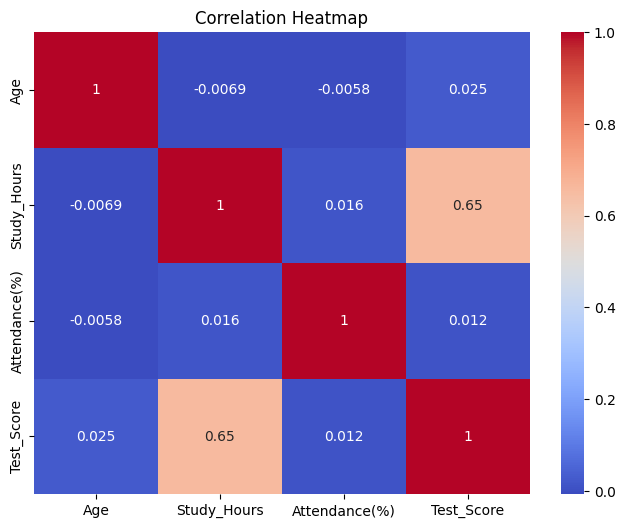

In [53]:
# Correlation Heatmap displaying relationships among numerical variables

import seaborn as sns
import numpy as np

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [54]:
# Does the number of study hours significantly influence students' test scores?

In [55]:
# Hypotheses
# Null Hypothesis (H₀)

# There is no significant relationship between Study Hours and Test Score.

# Alternative Hypothesis (H₁)

# There is a significant relationship between Study Hours and Test Score.

In [56]:
from scipy import stats

correlation, p_value = stats.pearsonr(
    df["Study_Hours"],
    df["Test_Score"]
)

print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: 0.6546701106112646
P-value: 2.0022420469951145e-123


In [57]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


In [58]:
# Since the p-value (2.00 × 10⁻¹²³) is less than 0.05, the Null Hypothesis (H₀) is rejected and the Alternative Hypothesis (H₁) is accepted.
# Therefore, there is a statistically significant positive relationship between study hours and test scores.
# Students who study more generally achieve higher test scores.